In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

from faker import Faker
fake = Faker()


con = duckdb.connect(database=':memory:')
con.execute("CREATE TABLE customers AS SELECT * FROM '../samples/customers.csv'")
customers = con.execute("""SELECT * FROM customers""").df();

In [2]:
def gen_graph(cust_daily_new, cust_running_total):
    fig, ax = plt.subplots(figsize=(14,4))
    cust_running_total.set_index('day').plot(ax=ax)
    cust_daily_new.set_index('day').plot(ax=ax, secondary_y=True)
    return ax

<Axes: xlabel='day'>

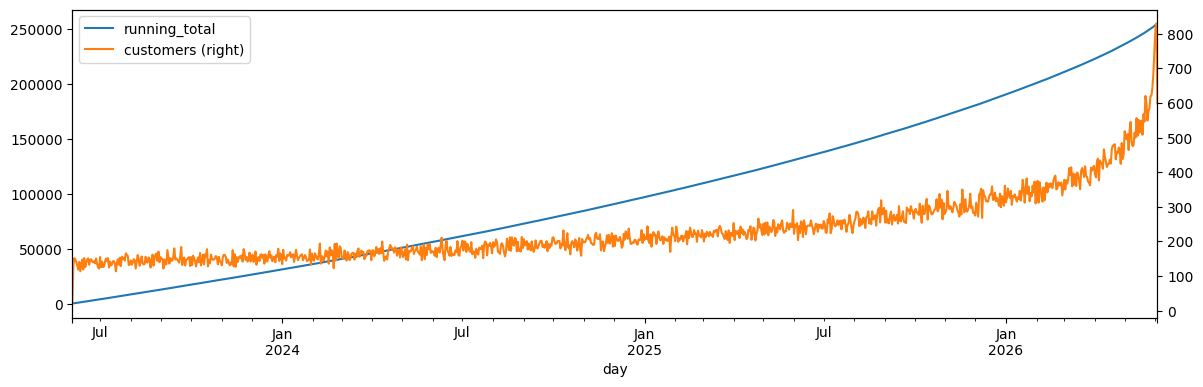

In [3]:
""" SQL version
"""
cust_daily_new = con.execute("""
select date_trunc('day', created_at) as day,
       count(*) as customers
from customers
group by 1
order by 1;
""").df()

cust_running_total = con.execute("""
select date_trunc('day', created_at) as day,
       sum(count(*)) over (
       order by date_trunc('day', created_at)) as running_total
from customers
group by 1
order by 1;
""").df()

gen_graph(cust_daily_new, cust_running_total)

<Axes: xlabel='day'>

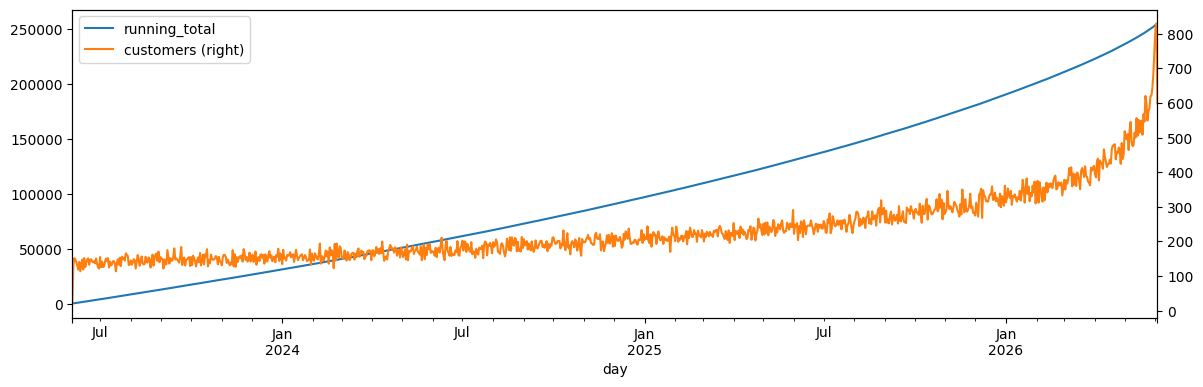

In [4]:
""" DataFrame version
"""
def generate_from_customrs(customers):
    cust_daily_new = (
        customers
            .groupby(customers['created_at'].dt.floor('D')).size()
            .reset_index(name='customers')
            .rename(columns={'created_at':'day'})
    )
    cust_running_total = (
        customers
            .groupby(customers['created_at'].dt.floor('D')).size()
            .reset_index(name='customers')
            .assign(
                running_total=lambda x: x['customers'].cumsum()
            ).drop(columns='customers')
            .rename(columns={'created_at':'day'})
    )
    return cust_daily_new, cust_running_total
    
cust_daily_new, cust_running_total = generate_from_customrs(customers)
gen_graph(cust_daily_new, cust_running_total)

In [5]:
customers2 = customers.copy()

In [6]:
customers2 = customers2.assign(
    created_at=lambda x: pd.Series(
        [fake.date_time_between(start_date='-3y',end_date='+2y').strftime('%Y-%m-%dT%H:%M:%S+00:00') for r in range(x.shape[0])],
        index=x.index
    ).astype('datetime64[us, UTC]').dt.tz_convert('America/Los_Angeles')
)

<Axes: xlabel='day'>

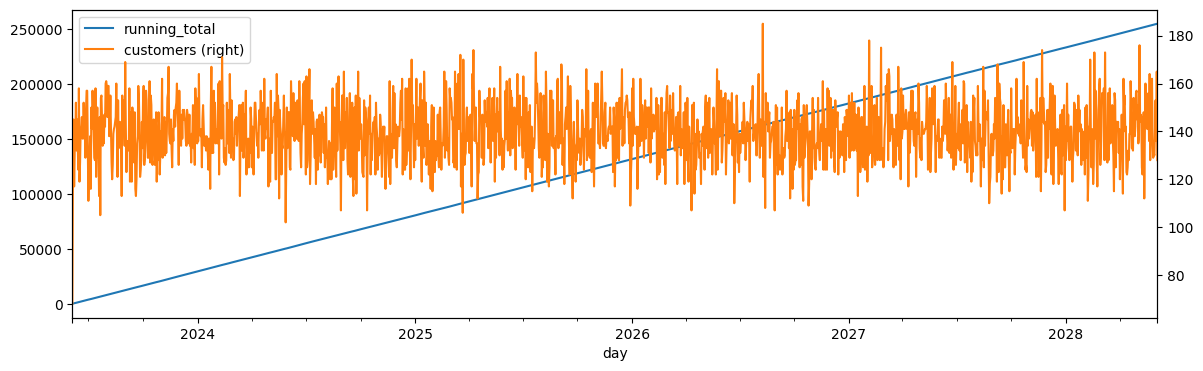

In [7]:
cust_daily_new, cust_running_total = generate_from_customrs(customers2)
gen_graph(cust_daily_new, cust_running_total)

In [8]:
target_address_id = 'addr_f356def7a0b4'
customers[customers.address_id == target_address_id].sort_values('created_at')

,customer_id,first_name,last_name,email,address_id,created_at
13053,cust_b1a1ee1aea05,Jeffrey,Mccarthy,jeffreymccarthy@mccullough-conrad.com,addr_f356def7a0b4,2023-07-01 11:42:42-07:00
224941,cust_fbb08c431d0e,Barbara,Mccarthy,barbara_mccarthy7w@example.net,addr_f356def7a0b4,2023-09-30 15:37:28-07:00
224940,cust_38332bc175a1,Patrick,Mccarthy,patrickmccarthy@hotmail.com,addr_f356def7a0b4,2023-11-21 16:08:10-08:00
170141,cust_7b4305f2b404,Natalie,Robinson,natalie_robinson@hotmail.com,addr_f356def7a0b4,2025-06-25 02:05:11-07:00
224939,cust_8e22de064386,Rodney,Mccarthy,rodne-mccarthy@hotmail.com,addr_f356def7a0b4,2025-07-06 03:59:42-07:00


In [9]:
mask = customers.sort_values('created_at')\
    .duplicated(subset='address_id', keep='first')\
    .reindex(customers.index, fill_value=False)
cust_primary = customers[~mask]
cust_household = customers[mask].sort_values(['address_id','created_at'])

<Axes: xlabel='day'>

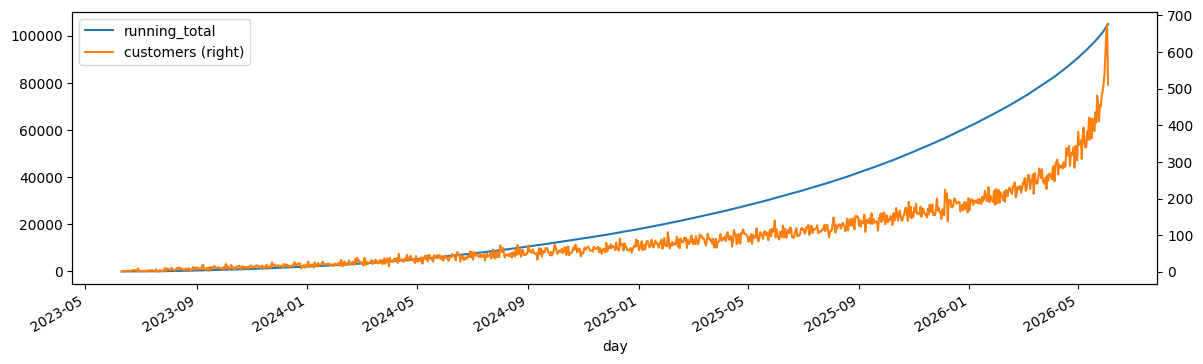

In [10]:
cust_daily_new, cust_running_total = generate_from_customrs(cust_household)
gen_graph(cust_daily_new, cust_running_total)

<Axes: xlabel='day'>

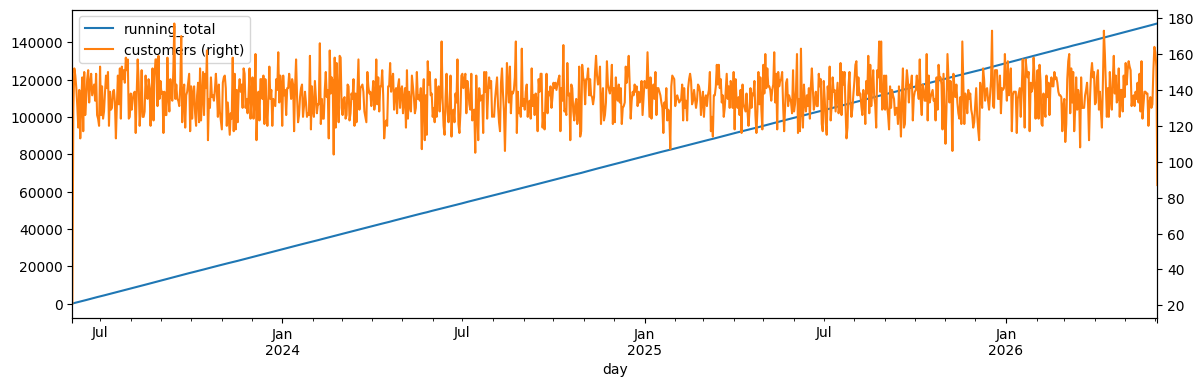

In [11]:
cust_daily_new, cust_running_total = generate_from_customrs(cust_primary)
gen_graph(cust_daily_new, cust_running_total)

## Seasonal `created_at` â€” prototype

Port the seasonal weight functions from `simulator/generator.py`, then resample `created_at` for primaries and household members separately.

In [12]:
import bisect
from datetime import datetime, timedelta, timezone
import random

# Window: 4 years back -> 2 years forward from today (ADR-018)
WINDOW_START = datetime(2023, 6, 1, tzinfo=timezone.utc)
WINDOW_END   = datetime(2028, 6, 1, tzinfo=timezone.utc)

# Seasonal weights -- identical to simulator/generator.py _MONTHLY_WEIGHT
_MONTHLY_WEIGHT = {
    1: 0.65, 2: 0.70, 3: 0.90, 4: 0.95,  5: 1.00,
    6: 1.05, 7: 1.10, 8: 1.05, 9: 1.00, 10: 1.10,
    11: 1.80, 12: 2.50,
}

def _seasonal_weight(dt):
    base = _MONTHLY_WEIGHT[dt.month]
    if dt.month == 12:
        if dt.day <= 15:   base *= 1.5
        elif dt.day <= 24: base *= 1.1
        else:              base *= 0.6
    return base

def _build_day_pool(start, end):
    days, weights = [], []
    cur = start.replace(hour=0, minute=0, second=0, microsecond=0)
    while cur < end:
        days.append(cur)
        weights.append(_seasonal_weight(cur))
        cur += timedelta(days=1)
    return days, weights

# ---------------------------------------------------------------------------
# Build the blended pool ONCE for the full window.
# blend=0.5: equal mix of seasonal signal and uniform baseline.
# Per-row sampling just bisects to the floor index and slices -- no rebuild.
# ---------------------------------------------------------------------------
_ALL_DAYS, _seasonal_w = _build_day_pool(WINDOW_START, WINDOW_END)
_max_w = max(_seasonal_w)
_ALL_BLENDED_W = [0.5 * s + 0.5 * _max_w for s in _seasonal_w]

def _sample_from_floor(floor, n=1):
    """Sample n dates from the pre-built blended pool, starting at floor.

    Uses bisect to find the slice index in O(log d) rather than rebuilding
    the pool (O(d)) on every call.  floor must be a tz-aware UTC datetime.
    """
    # Normalise floor to midnight so it aligns with pool day boundaries
    floor_day = floor.replace(hour=0, minute=0, second=0, microsecond=0)
    idx = bisect.bisect_left(_ALL_DAYS, floor_day)
    days_slice    = _ALL_DAYS[idx:]
    weights_slice = _ALL_BLENDED_W[idx:]
    if not days_slice:
        # floor is at or past WINDOW_END -- just return floor itself
        return [floor] * n
    chosen = random.choices(days_slice, weights=weights_slice, k=n)
    return [d + timedelta(seconds=random.randint(0, 86_399)) for d in chosen]

def _sample_dates_seasonal(n, start, end):
    """Sample n dates using pure seasonal weights (used for primaries)."""
    days, weights = _build_day_pool(start, end)
    chosen = random.choices(days, weights=weights, k=n)
    return [d + timedelta(seconds=random.randint(0, 86_399)) for d in chosen]

print(f'Window: {WINDOW_START.date()} -> {WINDOW_END.date()}  ({(WINDOW_END - WINDOW_START).days} days)')
print(f'Pool size: {len(_ALL_DAYS):,} days')


Window: 2023-06-01 -> 2028-06-01  (1827 days)
Pool size: 1,827 days


In [13]:
# Resample primaries -- full seasonal curve over the whole window
primary_dates = _sample_dates_seasonal(len(cust_primary), WINDOW_START, WINDOW_END)

cust_primary_new = cust_primary.copy()
cust_primary_new['created_at'] = (
    pd.Series(primary_dates, index=cust_primary.index)
    .dt.tz_convert ('UTC')
)

# Lookup: address_id -> new primary created_at (bounds household sampling)
primary_floor = cust_primary_new.set_index('address_id')['created_at'].to_dict()

print(f'Primaries resampled: {len(cust_primary_new):,}')
print(cust_primary_new['created_at'].describe())


Primaries resampled: 150,000
count                              150000
mean     2025-11-22 16:45:55.730913+00:00
min             2023-06-01 01:17:39+00:00
25%      2024-09-06 08:21:57.500000+00:00
50%      2025-11-28 20:44:59.500000+00:00
75%      2027-01-26 13:49:51.500000+00:00
max             2028-05-31 23:36:36+00:00
Name: created_at, dtype: object


<Axes: xlabel='day'>

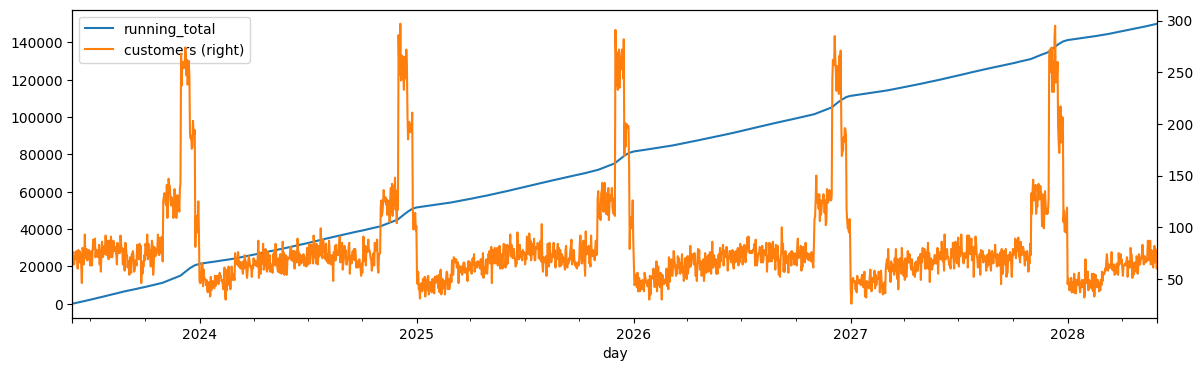

In [14]:
cust_daily_new, cust_running_total = generate_from_customrs(cust_primary_new)
gen_graph(cust_daily_new, cust_running_total)

In [15]:
cust_household_new = cust_household.copy()
primary_floor = cust_primary_new.set_index('address_id')['created_at'].reset_index()
cust_household_new = pd.merge(
    cust_household_new.drop(columns='created_at'),
    primary_floor,
    left_on='address_id',
    right_on='address_id',
    how='left'
)
cust_household_new = cust_household_new.assign(
    created_at=lambda x: [
        _sample_from_floor(r.created_at)[0]
        for r in x.itertuples()
    ]
)

<Axes: xlabel='day'>

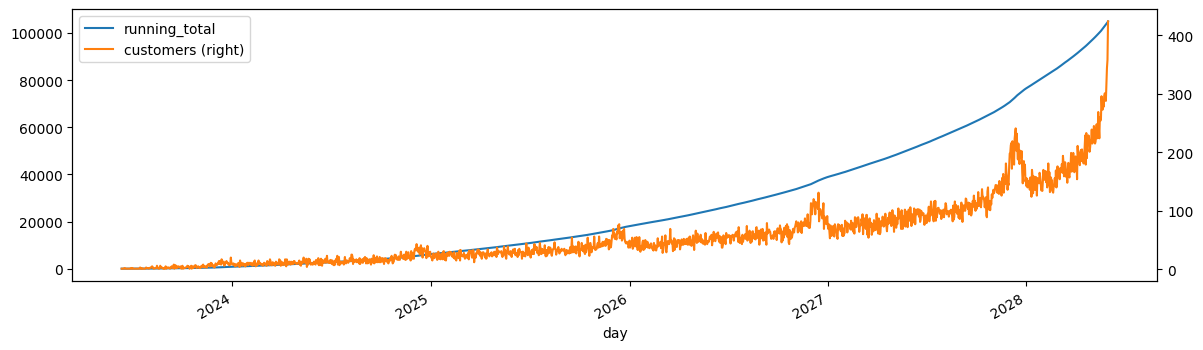

In [16]:
cust_daily_new, cust_running_total = generate_from_customrs(cust_household_new)
gen_graph(cust_daily_new, cust_running_total)

In [17]:
# Assemble and validate
customers_seasonal = pd.concat([cust_primary_new, cust_household_new]).sort_values('created_at')

# Sanity: no household member predates their primary
primary_min = customers_seasonal.groupby('address_id')['created_at'].min().rename('primary_min')
violations = (
    customers_seasonal
    .merge(primary_min, on='address_id')
    .query('created_at < primary_min')
)
print(f'Ordering violations: {len(violations)}  (expect 0)')
print(f'Total customers:     {len(customers_seasonal):,}')
print(f'Date range:          {customers_seasonal.created_at.min().date()} -> {customers_seasonal.created_at.max().date()}')


Ordering violations: 0  (expect 0)
Total customers:     254,935
Date range:          2023-06-01 -> 2028-05-31


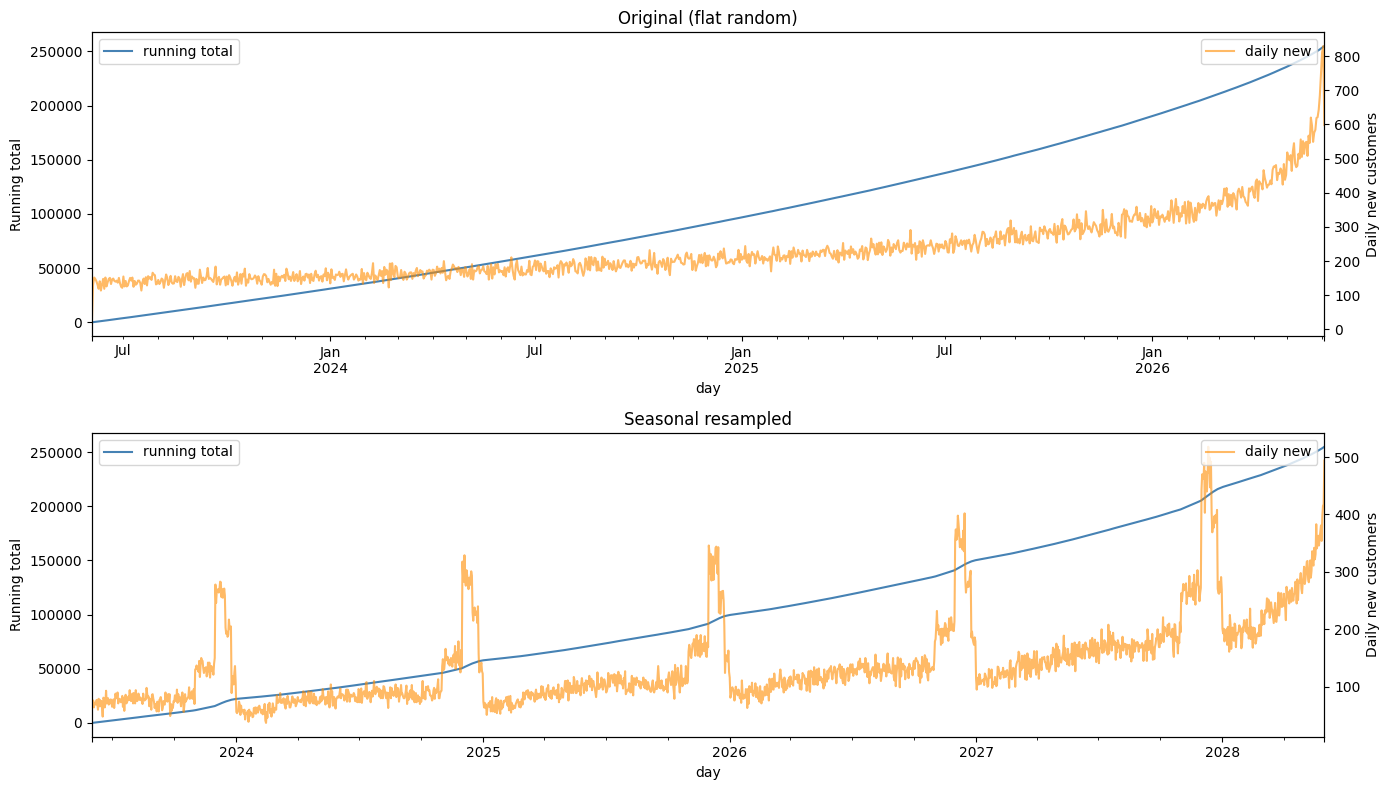

In [18]:
# Compare: original vs seasonal side-by-side
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, df, title in [
    (axes[0], customers,          'Original (flat random)'),
    (axes[1], customers_seasonal, 'Seasonal resampled'),
]:
    daily, total = generate_from_customrs(df)
    ax2 = ax.twinx()
    total.set_index('day')['running_total'].plot(ax=ax, color='steelblue', label='running total')
    daily.set_index('day')['customers'].plot(ax=ax2, color='darkorange', alpha=0.6, label='daily new')
    ax.set_title(title)
    ax.set_ylabel('Running total')
    ax2.set_ylabel('Daily new customers')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


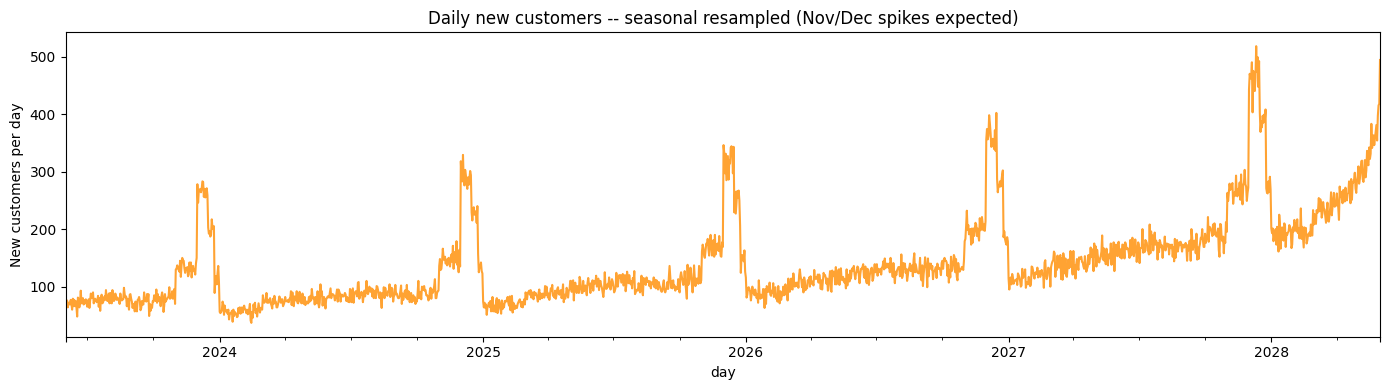

In [19]:
# Zoom: daily new only -- seasonal spikes (Nov/Dec) should be clearly visible
daily_new_seasonal, _ = generate_from_customrs(customers_seasonal)

fig, ax = plt.subplots(figsize=(14, 4))
daily_new_seasonal.set_index('day')['customers'].plot(ax=ax, color='darkorange', alpha=0.8)
ax.set_title('Daily new customers -- seasonal resampled (Nov/Dec spikes expected)')
ax.set_ylabel('New customers per day')
plt.tight_layout()
plt.show()
